# CryptoHedge — мультиагентная система хеджирования валютного риска криптовалют

**Единое автономное и воспроизводимое решение.** Ноутбук запускает все
**11 агентов** через оркестратор и пошагово показывает результаты: загрузку
данных, анализ волатильности и корреляций, калибровку модели **Хестона**,
расчёт греков, стратегию дельта-вега хеджирования, оптимизацию портфеля,
риск-менеджмент со стоп-лоссами, бэктестирование (walk-forward) и стресс-тесты,
самодиагностику, объяснение решений на естественном языке и интерактивный дашборд.

**Предпосылки.** Капитал $10 000 000; риск-аппетит и комиссии — в конфигурации;
горизонт анализа 3 месяца, горизонт прогноза 1 день; хеджируется валютный риск,
определяемый волатильностью криптовалют (первичный инструмент — BTC/USDT).

Подробная архитектура, роли агентов и маршрутизация сообщений — в
[`ARCHITECTURE.md`](ARCHITECTURE.md) и [`README.md`](README.md).

```mermaid
flowchart LR
    START((START)) --> DA[1 Data Acquisition] --> MA[2 Market Analysis] --> HC[3 Heston Calibration] --> GC[4 Greeks]
    GC --> HD[5 Hedging Decision] --> PO[6 Portfolio Opt] --> RM[7 Risk Mgmt] --> BT[8 Backtesting]
    BT --> SD[9 Self-Diagnostic] --> EX[10 Explainability] --> DB[11 Dashboard] --> END((DASHBOARD_READY))
```

## 0. Окружение и воспроизводимость

Находим корень проекта, фиксируем единый `seed` (через конфигурацию) и проверяем
версии ключевых библиотек. Все случайные процессы детерминированы — повторный
запуск даёт идентичные результаты.

In [1]:
import os
import sys
from pathlib import Path

# --- найти корень проекта (каталог, где лежат cryptohedge/ и config/) ---
root = Path.cwd()
while not ((root / "cryptohedge").is_dir() and (root / "config").is_dir()):
    if root.parent == root:
        raise RuntimeError("Не найден корень проекта (cryptohedge/ + config/)")
    root = root.parent
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("Корень проекта:", root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numba

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | "
      f"pandas {pd.__version__} | numba {numba.__version__}")

Корень проекта: C:\Users\user\Desktop\CMF\hedge fund


Python 3.11.1 | numpy 1.24.4 | pandas 2.0.3 | numba 0.57.1


## 1. Конфигурация и предпосылки инвестора

Все параметры системы вынесены в `config/*.yaml` и валидируются pydantic-моделями
(никакого хардкода в коде). Здесь задаются капитал, риск-аппетит, комиссии и
горизонты — далее они используются при калибровке Хестона, выборе инструментов,
оптимизации портфеля и расчёте прибыли.

In [2]:
from cryptohedge.core.config import load_config

config = load_config("config")

inv, hor, dat = config.investment, config.horizons, config.data
print("=== Предпосылки ===")
print(f"Капитал:                 ${inv.capital_usd:,.0f}")
print(f"Риск-аппетит (дн. VaR):  {inv.risk_budget_pct:.2%} капитала")
print(f"Комиссия (спот):         {inv.transaction_fee_pct:.4%}")
print(f"Комиссия (опцион):       {inv.option_fee_pct:.4%} (кап {inv.option_fee_cap_pct:.1%} от цены)")
print(f"Горизонт анализа:        {hor.analysis_days} дн.  | прогноз: {hor.forecast_days} дн.")
print(f"Вселенная:               {dat.universe_size} криптовалют, первичный {dat.primary_symbol}")
print(f"Опционы:                 экспирация {dat.option_expiry_days} дн., провайдер '{dat.provider}'")
print(f"Единый seed:             {config.seed}")

=== Предпосылки ===
Капитал:                 $10,000,000
Риск-аппетит (дн. VaR):  2.00% капитала
Комиссия (спот):         0.0300%
Комиссия (опцион):       0.0300% (кап 12.5% от цены)
Горизонт анализа:        90 дн.  | прогноз: 1 дн.
Вселенная:               100 криптовалют, первичный BTCUSDT
Опционы:                 экспирация 30 дн., провайдер 'bundled'
Единый seed:             90909090


## 2. Запуск мультиагентного конвейера

Создаём общий контекст (`AgentContext` — доска/blackboard + DI), собираем
конвейер из 11 агентов и запускаем оркестратор. Каждый агент логирует действия,
решения и время выполнения; результаты публикуются на доску и сохраняются как
чекпойнты. Сообщения маршрутизируются через шину (`MessageBus`).

> Первый запуск компилирует numba-ядра модели Хестона (разовый прогрев ~30–60 c).

In [3]:
from cryptohedge.agents import build_pipeline
from cryptohedge.core.context import AgentContext

# свежий прогон (без восстановления из чекпойнтов), чтобы ноутбук был автономным
config = load_config("config", overrides={"runtime": {"resume": False}})
context = AgentContext(config, root=root)
orchestrator = build_pipeline(context, fail_fast=True)
report = orchestrator.run()

summary = pd.DataFrame([
    {"agent": r.agent, "success": r.success, "seconds": round(r.duration_s, 2),
     "produces": r.message.type.value}
    for r in report.results
])
print(f"\nИтог: success={report.success}, суммарно {report.total_seconds():.1f} c, "
      f"сообщений в трейсе шины: {len(orchestrator.bus.trace)}")
summary

2026-06-20 15:43:31,848 | INFO    | data_acquisition       | started


2026-06-20 15:43:31,901 | INFO    | data_acquisition       | timing: load_data


2026-06-20 15:43:31,903 | INFO    | data_acquisition       | validation passed


2026-06-20 15:43:31,905 | INFO    | data_acquisition       | DECISION: loaded and validated market data


2026-06-20 15:43:31,906 | INFO    | data_acquisition       | timing: data_acquisition.execute


...

2026-06-20 15:44:57,507 | INFO    | dashboard              | timing: dashboard.execute


2026-06-20 15:44:57,510 | INFO    | dashboard              | completed


2026-06-20 15:44:57,510 | INFO    | orchestrator           | pipeline finished



Итог: success=True, суммарно 85.5 c, сообщений в трейсе шины: 23


,agent,success,seconds,produces
0,data_acquisition,True,0.06,data_ready
1,market_analysis,True,17.92,analysis_ready
2,heston_calibration,True,63.87,calibration_ready
3,greeks_calculation,True,0.42,greeks_ready
4,hedging_decision,True,0.72,hedge_decision
5,portfolio_optimization,True,0.80,portfolio_ready
6,risk_management,True,0.01,risk_assessment
7,backtesting,True,0.52,backtest_ready
8,self_diagnostic,True,0.00,diagnostic_ready
9,explainability,True,0.01,explanation_ready


## 3. Данные (Data Acquisition Agent)

Загружены спот-ряды 100 криптовалют (к USDT) за 3 месяца и опционная цепочка
пут/колл по BTC с экспирацией 30 дней. Агент валидирует данные, считает
лог-доходности и публикует их на доску.

Активов в спот-вселенной: 100 | срезов времени: 91
Опционных котировок BTC: 0 (страйков на срез: 0)


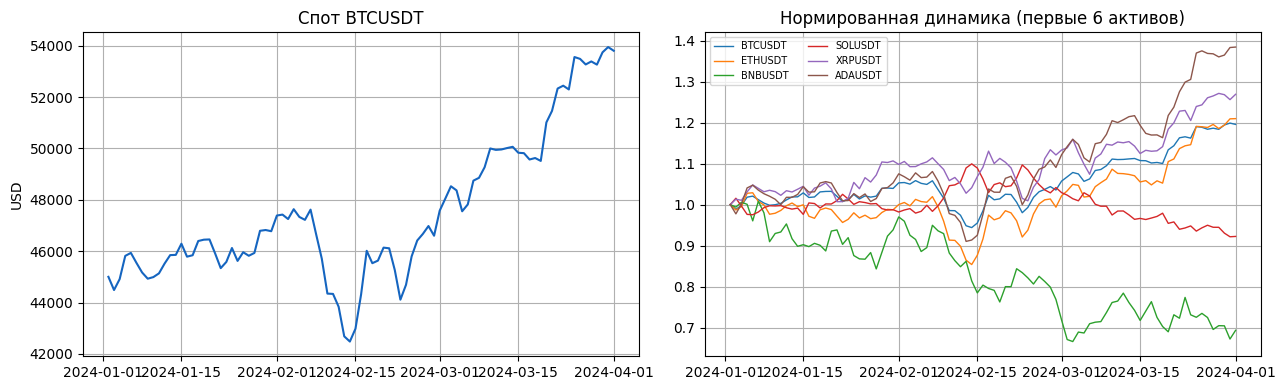

,sample_idx,timestamp,instrument_type,strike,expiry_ts,time_to_maturity,price,best_bid_price,best_ask_price,bid_amount_total,ask_amount_total,bid_vwap,ask_vwap
0,0,2024-01-02,7,0.0,0,0.000000,45000.000000,44995.500000,45004.500000,100.000000,100.000000,44995.500000,45004.500000
1,0,2024-01-02,5,18000.0,1714521600000000000,0.328767,0.600009,0.592924,0.607094,49.864327,40.593157,0.592924,0.607094
2,0,2024-01-02,5,23400.0,1714521600000000000,0.328767,0.480146,0.473908,0.486385,59.583200,46.355624,0.473908,0.486385
3,0,2024-01-02,5,28800.0,1714521600000000000,0.328767,0.361216,0.357034,0.365397,54.052477,46.003764,0.357034,0.365397


In [4]:
primary = context.get("primary_symbol")
spot_close = context.get("spot_close")
md = context.get("market_data")
symbols = context.get("symbols")

print(f"Активов в спот-вселенной: {len(symbols)} | срезов времени: {spot_close.shape[0]}")
opt = md[md["instrument_type"].isin(["call", "put"])]
print(f"Опционных котировок BTC: {len(opt)} "
      f"(страйков на срез: {opt[opt['sample_idx']==opt['sample_idx'].max()].shape[0]})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(pd.to_datetime(spot_close.index), spot_close[primary], color="#1565c0")
ax[0].set_title(f"Спот {primary}"); ax[0].set_ylabel("USD")
# нормированная динамика нескольких активов вселенной
for s in symbols[:6]:
    series = spot_close[s] / spot_close[s].iloc[0]
    ax[1].plot(pd.to_datetime(spot_close.index), series, label=s, lw=1)
ax[1].set_title("Нормированная динамика (первые 6 активов)"); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()
md.head(4)

## 4. Волатильность и объём хеджа (Market Analysis Agent)

Оцениваем суточную волатильность, волатильность суточной волатильности
(vol-of-vol) и доверительный интервал (хи-квадрат), затем переводим капитал и
риск-аппетит в объём первичного инструмента BTC/USDT, который нужно хеджировать.

In [5]:
vol = context.get("volatility")
sizing = context.get("hedge_sizing")
regime = context.get("regime")

print("=== Волатильность BTC/USDT ===")
print(f"Суточная волатильность:      {vol.daily_vol:.4%}")
print(f"Годовая волатильность:       {vol.annualized_vol:.2%}")
print(f"Vol-of-vol:                  {vol.vol_of_vol:.4%}")
print(f"Дов. интервал ({vol.confidence_level:.0%}):    [{vol.ci_low:.4%}, {vol.ci_high:.4%}]")
print(f"Текущий режим рынка:         {regime['label']}")
print("\n=== Объём первичного хеджа ===")
print(f"Незахеджированный дн. VaR:   {sizing.unhedged_var_pct:.4%}  (бюджет {sizing.target_var_pct:.4%})")
print(f"Доля хеджирования:           {sizing.hedge_ratio:.2%}")
print(f"Номинал к хеджированию:      ${sizing.notional_to_hedge_usd:,.0f}")
print(f"Объём BTC к хеджированию:    {sizing.quantity_to_hedge:.3f} BTC")

=== Волатильность BTC/USDT ===
Суточная волатильность:      1.2257%
Годовая волатильность:       23.42%
Vol-of-vol:                  0.3055%
Дов. интервал (95%):    [1.0691%, 1.4365%]
Текущий режим рынка:         calm

=== Объём первичного хеджа ===
Незахеджированный дн. VaR:   2.3629%  (бюджет 2.0000%)
Доля хеджирования:           15.36%
Номинал к хеджированию:      $1,535,724
Объём BTC к хеджированию:    28.543 BTC


## 5. Корреляции и рейтинг инструментов хеджирования

Помимо линейной корреляции Пирсона считаем ранговые Спирмена и Кендалла,
динамическую корреляцию **DCC-GARCH** и **коинтеграцию** (Engle-Granger /
Johansen). Инструменты ранжируются по 5 критериям: сила и устойчивость связи,
ликвидность, стоимость хеджирования и эффективность снижения риска.

Отобранная вселенная для хеджирования: ['SYN023USDT', 'SYN045USDT', 'SYN005USDT', 'ATOMUSDT', 'APTUSDT', 'ETHUSDT', 'SYN012USDT', 'SYN044USDT', 'LTCUSDT', 'SYN048USDT']


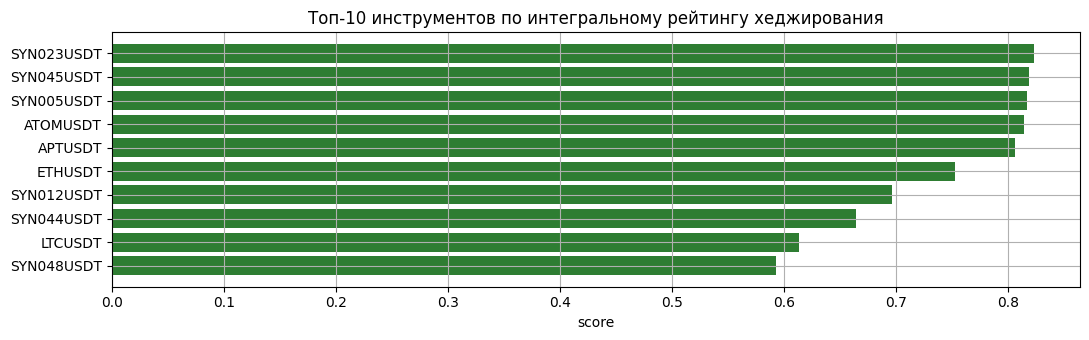

,symbol,score,relationship,pearson,spearman,kendall,dcc_mean,cointegrated,stability,risk_reduction
0,SYN023USDT,0.823,positive,0.999,0.999,0.976,0.999,False,1.000,0.965
1,SYN045USDT,0.819,positive,0.999,0.998,0.968,0.999,False,0.999,0.957
2,SYN005USDT,0.817,positive,0.999,0.997,0.968,0.999,False,0.999,0.960
3,ATOMUSDT,0.814,positive,0.999,0.998,0.971,0.999,False,1.000,0.961
4,APTUSDT,0.806,positive,0.999,0.998,0.972,0.999,False,1.000,0.963
5,ETHUSDT,0.753,positive,0.963,0.951,0.817,0.952,False,0.972,0.730
6,SYN012USDT,0.696,positive,0.950,0.925,0.774,0.941,True,0.973,0.687
7,SYN044USDT,0.664,positive,0.936,0.906,0.748,0.925,True,0.966,0.648
8,LTCUSDT,0.613,positive,0.956,0.931,0.787,0.949,False,0.976,0.706
9,SYN048USDT,0.593,positive,0.956,0.938,0.797,0.943,False,0.973,0.706


In [6]:
rankings_df = context.get("rankings_df")
hedge_universe = context.get("hedge_universe")
print("Отобранная вселенная для хеджирования:", hedge_universe)

cols = [c for c in ["symbol", "score", "relationship", "pearson", "spearman",
                    "kendall", "dcc_mean", "cointegrated", "stability",
                    "risk_reduction"] if c in rankings_df.columns]
top = rankings_df[cols].head(10).round(3)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.barh(top["symbol"][::-1], top["score"][::-1], color="#2e7d32")
ax.set_title("Топ-10 инструментов по интегральному рейтингу хеджирования")
ax.set_xlabel("score"); plt.tight_layout(); plt.show()
top

## 6. Калибровка модели Хестона + бенчмарки (Black-Scholes, SABR)

Параметры Хестона калибруются по поверхности подразумеваемой волатильности на
каждом срезе (и независимо через MLE по ряду спота). Контролируется устойчивость
параметров во времени; качество сравнивается с Black-Scholes и SABR.

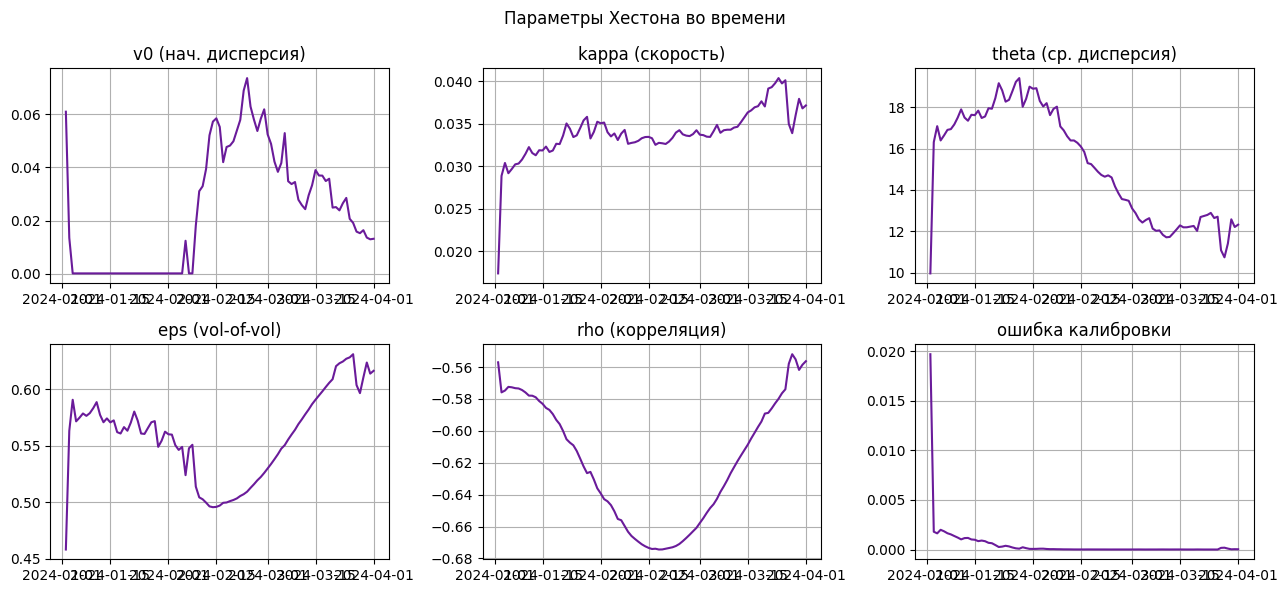

Устойчивость параметров: stable=False, макс. отн. изменение=180.382
MLE (по ряду спота): v0=0.0461, kappa=9.271, theta=0.0553, eps=0.438, rho=-0.075

=== Бенчмарки (RMSE подразумеваемой волатильности на среднем срезе) ===
Heston:        0.00023
Black-Scholes: 0.75212
SABR:          0.76371


In [7]:
calibr = context.get("calibr_data").sort_values("sample_idx")
stability = context.get("heston_stability")
benchmarks = context.get("heston_benchmarks")
mle = context.get("heston_mle")

t = pd.to_datetime(calibr["timestamp"])
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, p, name in zip(axes.ravel(),
                       ["v0", "kappa", "theta", "eps", "rho", "calibration_error"],
                       ["v0 (нач. дисперсия)", "kappa (скорость)", "theta (ср. дисперсия)",
                        "eps (vol-of-vol)", "rho (корреляция)", "ошибка калибровки"]):
    ax.plot(t, calibr[p], color="#6a1b9a"); ax.set_title(name)
plt.suptitle("Параметры Хестона во времени"); plt.tight_layout(); plt.show()

print(f"Устойчивость параметров: stable={stability['stable']}, "
      f"макс. отн. изменение={stability['max_rel_change']:.3f}")
print(f"MLE (по ряду спота): v0={mle.v0:.4f}, kappa={mle.kappa:.3f}, theta={mle.theta:.4f}, "
      f"eps={mle.eps:.3f}, rho={mle.rho:.3f}")
print("\n=== Бенчмарки (RMSE подразумеваемой волатильности на среднем срезе) ===")
print(f"Heston:        {benchmarks.get('heston', {}).get('iv_rmse', float('nan')):.5f}")
print(f"Black-Scholes: {benchmarks.get('black_scholes', {}).get('iv_rmse', float('nan')):.5f}")
print(f"SABR:          {benchmarks.get('sabr', {}).get('rmse', float('nan')):.5f}")

## 7. Греки портфеля (Greeks Calculation Agent)

Считаем дельту и вегу, а также гамму, тету, ро и charm (плюс vanna/volga) для
оценки устойчивости хеджа. Греки агрегируются по портфелю и рассчитываются вдоль
сетки страйков (moneyness).

=== Агрегированные греки портфеля (последний срез) ===
  delta  : -0.0933
  gamma  : 0.0001
  vega   : 3,121.7650
  theta  : -26.9778
  rho    : -417.9033
  vanna  : -1.6456
  volga  : 59,791.4037
  charm  : 0.0138

Статус баланса дельты: green (|Δ|/капитал = 0.0005)


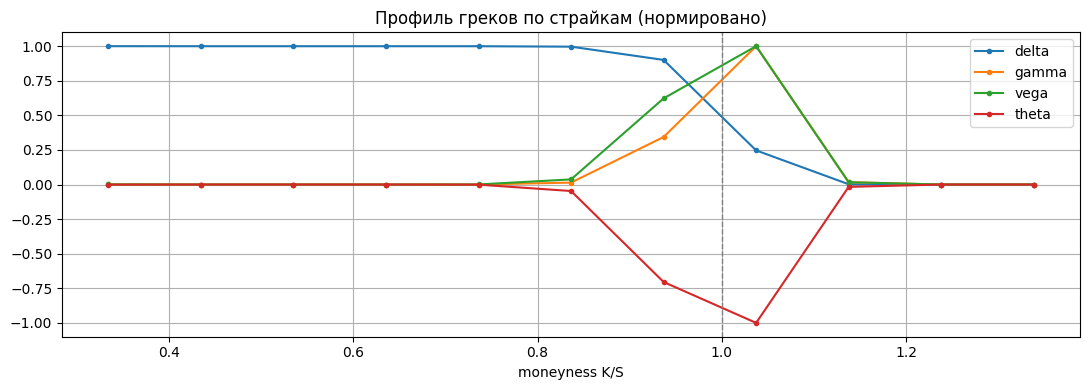

In [8]:
pg = context.get("portfolio_greeks_latest")
chain = context.get("chain_greeks")
status = context.get("hedge_status")

print("=== Агрегированные греки портфеля (последний срез) ===")
for k in ["delta", "gamma", "vega", "theta", "rho", "vanna", "volga", "charm"]:
    if k in pg:
        print(f"  {k:<7}: {pg[k]:,.4f}")
print(f"\nСтатус баланса дельты: {status.get('zone', 'n/a')} "
      f"(|Δ|/капитал = {status.get('delta_fraction', float('nan')):.4f})")

# греки вдоль страйков
gcols = [c for c in ["delta", "gamma", "vega", "theta"] if c in chain.columns]
fig, ax = plt.subplots(figsize=(11, 4))
for c in gcols:
    ax.plot(chain["moneyness"], chain[c] / chain[c].abs().max(), marker="o", ms=3, label=c)
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.set_title("Профиль греков по страйкам (нормировано)"); ax.set_xlabel("moneyness K/S")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Стратегия хеджирования Хестона (Hedging Decision Agent)

Движок повторяет логику `heston_greeks_hedging.ipynb`: на каждом шаге
ребалансирует спот (дельта-хедж) и опцион (вега-хедж), нейтрализуя дельту и вегу
портфеля. Отслеживаются цена спота, PnL, уплаченные комиссии, позиции и премия
опционного портфеля.

=== Последнее решение по хеджированию ===
Спот:                53,804.31
Дельта портфеля:     -0.0933  ->  дельта-хедж -0.0933
Вега портфеля:       3,121.76  ->  вега-хедж 3,121.76
Остаточная Δ / ν:    1.42e-15 / 0.00e+00
Позиция спот:        -28.5428 BTC
Позиция вега-опцион: 28.5428
PnL стратегии:       $-5,747.75  | комиссии: $760.91 | сделок: 111


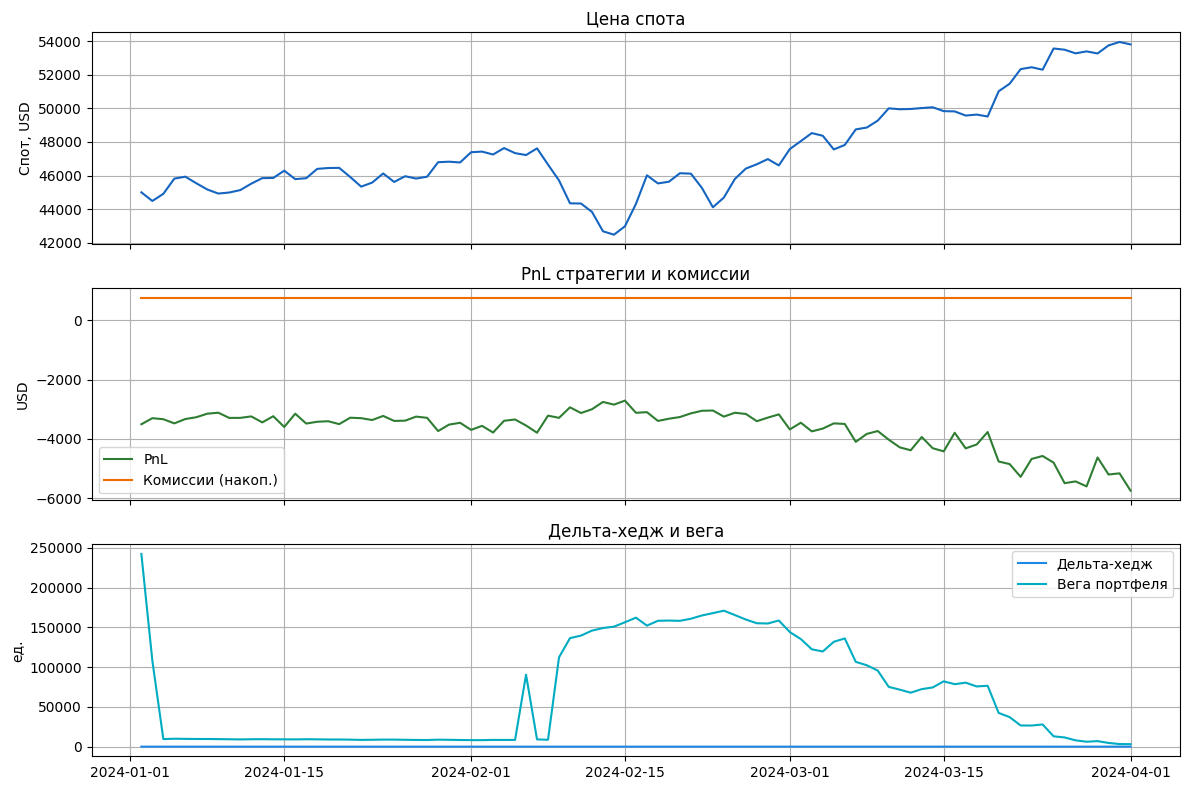

In [9]:
hist = context.get("hedge_history")
dec = context.get("latest_decision")

print("=== Последнее решение по хеджированию ===")
print(f"Спот:                {dec['spot']:,.2f}")
print(f"Дельта портфеля:     {dec['portfolio_delta']:,.4f}  ->  дельта-хедж {dec['delta_hedge']:,.4f}")
print(f"Вега портфеля:       {dec['portfolio_vega']:,.2f}  ->  вега-хедж {dec['vega_hedge']:,.2f}")
print(f"Остаточная Δ / ν:    {dec['residual_delta']:.2e} / {dec['residual_vega']:.2e}")
print(f"Позиция спот:        {dec['pos_spot']:,.4f} BTC")
print(f"Позиция вега-опцион: {dec['pos_vega_option']:,.4f}")
print(f"PnL стратегии:       ${dec['pnl']:,.2f}  | комиссии: ${dec['fees']:,.2f} | сделок: {dec['n_trades']}")

ts = pd.to_datetime(hist["ts"])
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(ts, hist["spot"], color="#1565c0"); ax[0].set_ylabel("Спот, USD"); ax[0].set_title("Цена спота")
ax[1].plot(ts, hist["pnl"], color="#2e7d32", label="PnL"); ax[1].plot(ts, hist["fee"], color="#ef6c00", label="Комиссии (накоп.)")
ax[1].set_ylabel("USD"); ax[1].legend(); ax[1].set_title("PnL стратегии и комиссии")
ax[2].plot(ts, hist["delta_hedge"], color="#1e88e5", label="Дельта-хедж")
ax[2].plot(ts, hist["vega"], color="#00acc1", label="Вега портфеля")
ax[2].set_ylabel("ед."); ax[2].legend(); ax[2].set_title("Дельта-хедж и вега")
plt.tight_layout(); plt.show()

## 9. Оптимизация портфеля: диверсификация и прибыльность (Portfolio Optimization Agent)

Агент строит **инвестиционный портфель** пятью методами (Mean-Variance, Risk
Parity, Minimum Variance, Maximum Diversification, CVaR), для каждого прогоняет
**бэктест с ребалансировкой** (с учётом комиссий) и автоматически выбирает метод,
который одновременно **прибылен** и **максимально диверсифицирован**.

Высокая диверсификация подтверждается метриками: коэффициент диверсификации
(DR ≥ 1, чем больше — тем лучше), эффективное число активов (обратный индекс
Херфиндаля), максимальный вес и индекс концентрации HHI. Ниже показаны: состав
портфеля, динамика его стоимости с отметками ребалансировки и эволюция весов.

Сравнение методов (бэктест с ребалансировкой, нетто комиссий):


,total_return,sharpe,diversification_ratio,effective_n,max_drawdown
method,,,,,
mean_variance,0.4072,6.2032,1.1601,5.3880,-0.0798
risk_parity,0.4209,6.1248,1.6298,13.6962,-0.0953
min_variance,0.3646,5.6365,1.7490,5.9995,-0.0890
max_diversification,0.3853,5.7794,1.8800,6.6773,-0.0857
cvar,0.3019,4.9046,1.5151,6.1407,-0.0990


Выбран метод: 'risk_parity' — прибыльный и максимально диверсифицированный.

=== Диверсификация выбранного портфеля ===
Коэффициент диверсификации:  1.63  (бенчмарк 1.55)
Эффективное число активов:   13.7  из 15
Максимальный вес актива:     12.6%
Индекс концентрации (HHI):   0.073
Число ребалансировок:        13
Доходность портфеля:         42.1%  (бенчмарк 44.3%)

=== Состав портфеля ===


,инструмент,"вес,%","дох-ть,%/год","волат.,%/год",связь с BTC
0,SNXUSDT,10.65,102.0,26.2,positive
1,ZECUSDT,8.73,297.0,86.8,neutral
2,SYN033USDT,8.48,127.3,35.1,weak
3,SYN050USDT,7.56,127.8,33.7,positive
4,GALAUSDT,7.29,114.4,33.8,positive
5,DASHUSDT,7.28,121.9,29.6,positive
6,ARBUSDT,7.11,129.0,35.3,positive
7,XLMUSDT,6.81,135.7,28.9,positive
8,SYN011USDT,6.68,127.9,36.7,positive
9,LINKUSDT,5.96,120.2,36.1,positive


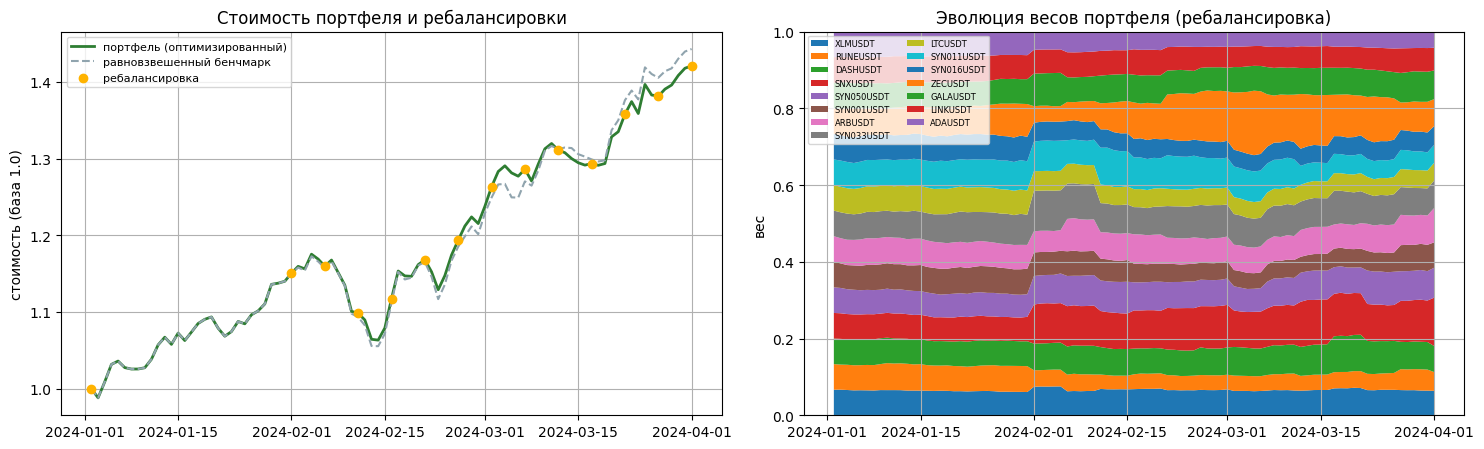

In [10]:
reb = context.get("rebalance_decision")
methods = context.get("method_comparison")
constituents = context.get("portfolio_constituents")
div = context.get("diversification")
equity = context.get("portfolio_equity")
wpath = context.get("portfolio_weights_path")

# 1) сравнение методов по бэктесту с ребалансировкой
comp = methods.set_index("method")[["total_return", "sharpe", "diversification_ratio",
                                     "effective_n", "max_drawdown"]].round(4)
print("Сравнение методов (бэктест с ребалансировкой, нетто комиссий):")
display(comp)
print(f"Выбран метод: '{reb['method']}' — прибыльный и максимально диверсифицированный.")

# 2) подтверждение высокой диверсификации
print("\n=== Диверсификация выбранного портфеля ===")
print(f"Коэффициент диверсификации:  {div['diversification_ratio']:.2f}  (бенчмарк {div['benchmark_diversification_ratio']:.2f})")
print(f"Эффективное число активов:   {div['effective_n']:.1f}  из {div['n_assets']}")
print(f"Максимальный вес актива:     {div['max_weight']:.1%}")
print(f"Индекс концентрации (HHI):   {div['hhi']:.3f}")
print(f"Число ребалансировок:        {div['n_rebalances']}")
print(f"Доходность портфеля:         {comp.loc[reb['method'], 'total_return']:.1%}  "
      f"(бенчмарк {float(equity['benchmark'].iloc[-1]-1):.1%})")

# 3) состав портфеля (инструменты и веса)
print("\n=== Состав портфеля ===")
display(constituents.assign(
    **{"вес,%": (constituents["weight"] * 100).round(2),
       "дох-ть,%/год": (constituents["exp_return_annual"] * 100).round(1),
       "волат.,%/год": (constituents["vol_annual"] * 100).round(1)}
).rename(columns={"symbol": "инструмент", "relationship": "связь с BTC"})
[["инструмент", "вес,%", "дох-ть,%/год", "волат.,%/год", "связь с BTC"]])

# 4) динамика стоимости с ребалансировкой + эволюция весов
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
eq_ts = pd.to_datetime(equity["ts"])
ax[0].plot(eq_ts, equity["equity"], label="портфель (оптимизированный)", color="#2e7d32", lw=2)
ax[0].plot(eq_ts, equity["benchmark"], label="равновзвешенный бенчмарк", color="#90a4ae", ls="--")
rebs = pd.to_datetime([str(r) for r in context.get("portfolio_rebalances", [])])
reb_idx = pd.Index(eq_ts).get_indexer(rebs, method="nearest")
ax[0].scatter(eq_ts.iloc[reb_idx], equity["equity"].iloc[reb_idx], color="#ffb300", zorder=5,
              label="ребалансировка")
ax[0].set_title("Стоимость портфеля и ребалансировки"); ax[0].set_ylabel("стоимость (база 1.0)")
ax[0].legend(fontsize=8)

w_ts = pd.to_datetime(wpath["ts"])
acols = [c for c in wpath.columns if c != "ts"]
ax[1].stackplot(w_ts, *[wpath[c] for c in acols], labels=acols)
ax[1].set_title("Эволюция весов портфеля (ребалансировка)"); ax[1].set_ylabel("вес"); ax[1].set_ylim(0, 1)
ax[1].legend(fontsize=6, ncol=2, loc="upper left")
plt.tight_layout(); plt.show()

## 10. Риск-менеджмент: VaR/CVaR и адаптивные стоп-лоссы (Risk Management Agent)

Контролируем VaR, CVaR и Expected Shortfall захеджированной книги против лимитов.
Стоп-лосс адаптивный (учитывает волатильность, ATR, VaR и параметры Хестона) и
дополнен динамическим трейлинг-стопом.

=== Оценка риска захеджированной книги ===
VaR:               0.0055%  (лимит 5.00%)
CVaR / ES:         0.0069%
Макс. просадка:    -0.0304%  (лимит 25.00%)
В пределах лимитов: True  | нарушено: —

=== Адаптивный стоп-лосс ===
Цена входа/референс: 53,804.31
Уровень стопа:      50,248.07  (дистанция 6.61%, метод atr+var+heston)
Компоненты: ATR=6.61%, VaR=2.93%, Heston=0.90%


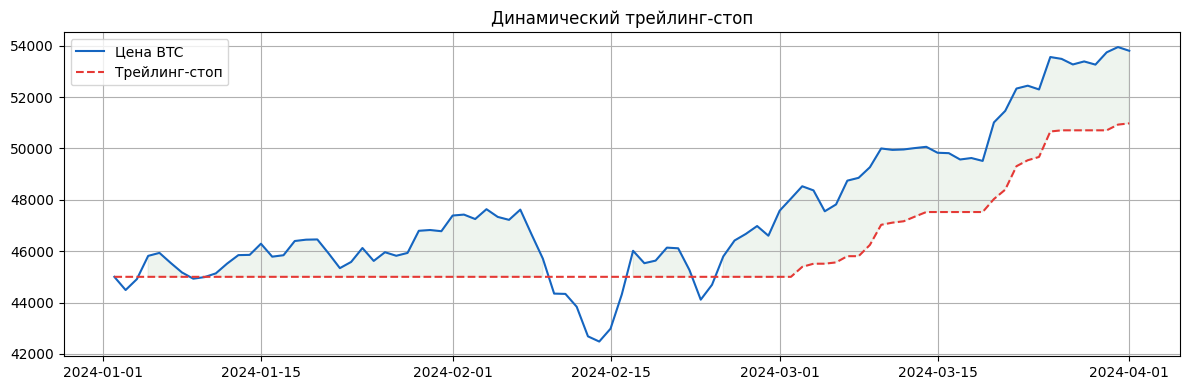

In [11]:
risk = context.get("risk_assessment")
stop = context.get("stop_level")
trailing = context.get("trailing_stops")

print("=== Оценка риска захеджированной книги ===")
print(f"VaR:               {risk['var']:.4%}  (лимит {config.risk.var_limit_pct:.2%})")
print(f"CVaR / ES:         {risk['cvar']:.4%}")
print(f"Макс. просадка:    {risk['max_drawdown']:.4%}  (лимит {config.risk.max_drawdown_limit_pct:.2%})")
print(f"В пределах лимитов: {risk['within_limits']}  | нарушено: {risk['breached_limits'] or '—'}")
print("\n=== Адаптивный стоп-лосс ===")
print(f"Цена входа/референс: {stop['reference_price']:,.2f}")
print(f"Уровень стопа:      {stop['stop_price']:,.2f}  (дистанция {stop['distance_pct']:.2%}, метод {stop['method']})")
print(f"Компоненты: ATR={stop['components']['atr_pct']:.2%}, "
      f"VaR={stop['components']['var_pct']:.2%}, Heston={stop['components']['heston_vol_pct']:.2%}")

if trailing is not None and not trailing.empty:
    tt = pd.to_datetime(trailing["ts"])
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(tt, trailing["price"], color="#1565c0", label="Цена BTC")
    ax.plot(tt, trailing["stop_price"], color="#e53935", ls="--", label="Трейлинг-стоп")
    ax.fill_between(tt, trailing["stop_price"], trailing["price"],
                    where=trailing["price"] >= trailing["stop_price"], color="#2e7d32", alpha=0.08)
    ax.set_title("Динамический трейлинг-стоп"); ax.legend(); plt.tight_layout(); plt.show()

## 11. Бэктестирование (walk-forward) и стресс-тесты (Backtesting Agent)

Бэктест выполнен через walk-forward валидацию без утечки будущего (purge/embargo),
с учётом survivorship/selection/transaction-cost bias. Рассчитан полный набор
портфельных метрик; проведены стресс-тесты на экстремальных движениях ±5%/±10% и
скачке волатильности.

=== Ключевые портфельные метрики ===


,метрика,значение
0,ROI,-0.0002
1,Sharpe,-1.5378
2,Sortino,-2.2304
3,Calmar,-2.9574
4,Max Drawdown,-0.0003
5,Profit Factor,0.8032
6,Win Rate,0.5275
7,VaR,0.0001
8,CVaR,0.0001
9,Expected Shortfall,0.0001


Контроль смещений: {'survivorship_bias': {'controlled': True, 'note': 'Full universe retained across the window; no winners-only selection.'}, 'selection_bias': {'controlled': True, 'note': 'Hedge universe ranked on in-sample data only; no peeking at test folds.'}, 'transaction_cost_bias': {'controlled': True, 'note': 'Spot and option fees (incl. cap) charged on every trade.'}, 'look_ahead': {'controlled': True, 'note': 'Walk-forward folds with purge/embargo; per-slice calibration is contemporaneous.'}}


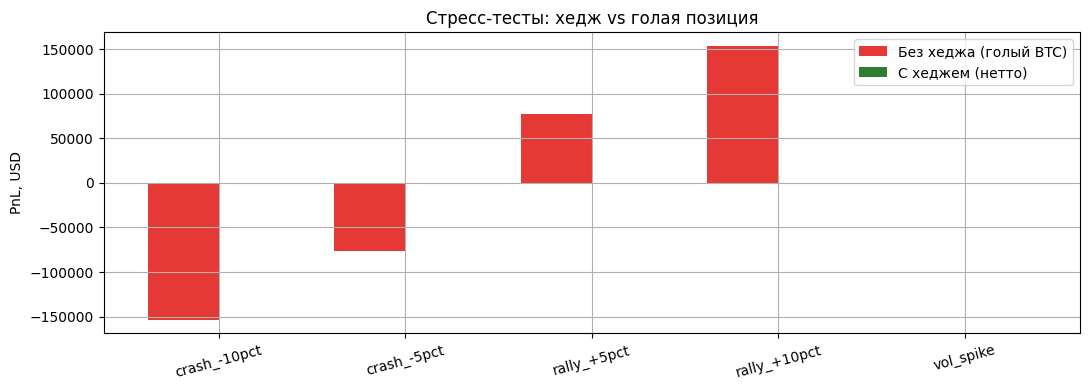

,scenario,spot_shock,vol_shock,liability_pnl,spot_hedge_pnl,option_hedge_pnl,net_hedged_pnl,unhedged_pnl,hedge_effectiveness
0,crash_-10pct,-0.10,0.50,-4865.75,153572.36,-148706.61,-0.0,-153572.36,1.0
1,crash_-5pct,-0.05,0.25,-801.71,76786.18,-75984.47,-0.0,-76786.18,1.0
2,rally_+5pct,0.05,-0.10,125.70,-76786.18,76660.48,0.0,76786.18,1.0
3,rally_+10pct,0.10,-0.20,147.44,-153572.36,153424.91,0.0,153572.36,1.0
4,vol_spike,0.00,1.00,-231.88,-0.00,231.88,-0.0,0.00,1.0


In [12]:
perf = context.get("backtest_metrics")
wf = context.get("walkforward")
stress = context.get("stress_table")
bias = context.get("bias_controls")

labels = {"roi": "ROI", "sharpe": "Sharpe", "sortino": "Sortino", "calmar": "Calmar",
          "max_drawdown": "Max Drawdown", "profit_factor": "Profit Factor", "win_rate": "Win Rate",
          "var": "VaR", "cvar": "CVaR", "expected_shortfall": "Expected Shortfall",
          "beta": "Beta", "alpha": "Alpha", "information_ratio": "Information Ratio",
          "volatility": "Volatility"}
metrics_tbl = pd.DataFrame({"метрика": [labels[k] for k in labels if k in perf],
                            "значение": [round(perf[k], 4) for k in labels if k in perf]})
print("=== Ключевые портфельные метрики ===")
display(metrics_tbl)
print("Контроль смещений:", bias)

# стресс: захеджированный портфель vs голый BTC
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(stress)); w = 0.38
ax.bar(x - w/2, stress["unhedged_pnl"], w, label="Без хеджа (голый BTC)", color="#e53935")
ax.bar(x + w/2, stress["net_hedged_pnl"], w, label="С хеджем (нетто)", color="#2e7d32")
ax.set_xticks(x); ax.set_xticklabels(stress["scenario"], rotation=15)
ax.set_ylabel("PnL, USD"); ax.set_title("Стресс-тесты: хедж vs голая позиция"); ax.legend()
plt.tight_layout(); plt.show()
stress.round(2)

=== Walk-forward валидация (по фолдам) ===


,fold,train_start,train_end,test_start,test_end,roi,sharpe,sortino,max_drawdown,pnl_end
0,0,0,29,30,34,0.0000,5.9451,0.0000,-0.0000,351.4722
1,1,5,34,35,39,0.0001,7.0317,19.6623,-0.0000,614.4804
2,2,10,39,40,44,0.0000,12.1816,0.0000,-0.0000,418.5831
3,3,15,44,45,49,-0.0000,-3.5916,0.0000,-0.0000,-142.9948
4,4,20,49,50,54,0.0000,0.6065,0.0000,-0.0000,20.5690
5,5,25,54,55,59,-0.0001,-7.4039,-10.6300,-0.0001,-522.0203
6,6,30,59,60,64,-0.0000,-0.9049,-0.8277,-0.0000,-41.9134
7,7,35,64,65,69,-0.0000,-2.9863,-30.3407,-0.0001,-185.9394
8,8,40,69,70,74,0.0001,5.4682,11.7628,-0.0000,590.5305
9,9,45,74,75,79,-0.0001,-3.8011,-3.1514,-0.0001,-530.3961


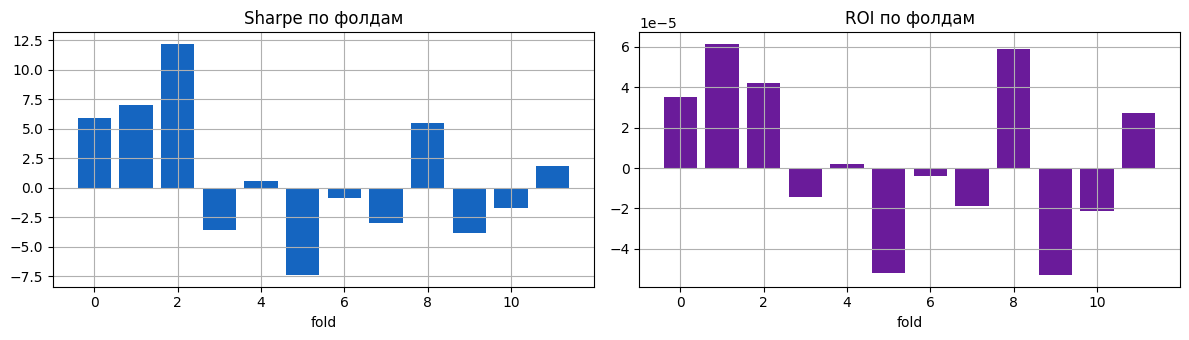

In [13]:
print("=== Walk-forward валидация (по фолдам) ===")
display(wf.round(4))

if not wf.empty:
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    ax[0].bar(wf["fold"], wf["sharpe"], color="#1565c0"); ax[0].set_title("Sharpe по фолдам"); ax[0].set_xlabel("fold")
    ax[1].bar(wf["fold"], wf["roi"], color="#6a1b9a"); ax[1].set_title("ROI по фолдам"); ax[1].set_xlabel("fold")
    plt.tight_layout(); plt.show()

## 12. Самодиагностика и индекс доверия (Self-Diagnostic Agent)

Контроль деградации качества моделей, мониторинг ошибок прогнозирования и дрейфа
распределений данных (PSI/KS) сводятся в интегральный **Confidence Score**.

Confidence Score: 0.475  ->  оценка: low_confidence


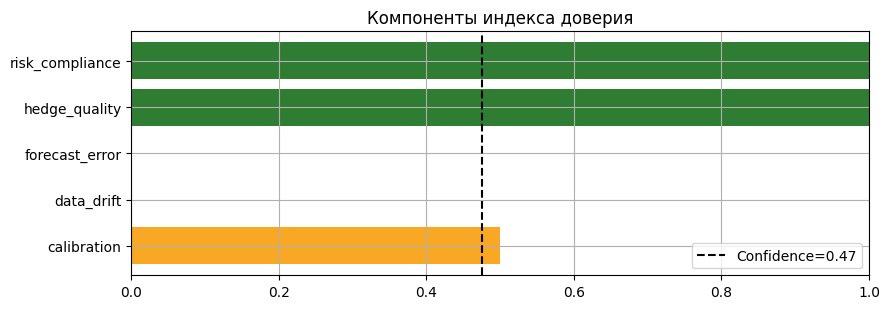

{'psi': 1.4559,
 'ks': {'statistic': 0.2, 'pvalue': 0.33194772679901},
 'drift_detected': True,
 'forecast_error': {'rmse': 0.009066558405015425,
  'mae': 0.007178593555697007,
  'bias': 0.0026928753604461373},
 'stability': {'stable': False,
  'max_rel_change': 180.3816917708476,
  'mean_rel_change': 0.7083574764598781,
  'per_param': {'v0': 3.472698760918564,
   'kappa': 0.02504670716478074,
   'theta': 0.02616511325517995,
   'eps': 0.013053849679589441,
   'rho': 0.004822951281274856}},
 'residual_delta_usd': 0.0,
 'residual_delta_fraction': 0.0,
 'confidence_score': 0.4749,
 'self_assessment': 'low_confidence'}

In [14]:
diag = context.get("diagnostic")
cs = float(context.get("confidence_score"))

print(f"Confidence Score: {cs:.3f}  ->  оценка: {diag.get('self_assessment', 'n/a')}")
comp = diag.get("components", {})
if comp:
    fig, ax = plt.subplots(figsize=(9, 3.2))
    names = list(comp.keys()); vals = [float(comp[k]) for k in names]
    colors = ["#2e7d32" if v >= 0.6 else "#f9a825" if v >= 0.4 else "#e53935" for v in vals]
    ax.barh(names, vals, color=colors); ax.set_xlim(0, 1)
    ax.axvline(cs, color="black", ls="--", label=f"Confidence={cs:.2f}")
    ax.set_title("Компоненты индекса доверия"); ax.legend(); plt.tight_layout(); plt.show()
{k: (round(v, 4) if isinstance(v, float) else v) for k, v in diag.items() if k != "components"}

## 13. Объяснение решений на естественном языке (Explainability Agent)

Отдельный агент формирует объяснение текущей ситуации: риски, выбор инструментов,
калибровка, баланс греков, **оптимизация портфеля и диверсификация**, лимиты/стопы,
результаты бэктеста и индекс доверия — каждое утверждение подкреплено
количественными метриками. Объяснение формируется на **двух языках** —
русском (`explanation.md`) и английском (`explanation.en.md`); ниже показана
русская версия.

In [15]:
from IPython.display import Markdown, display

sections = context.get("explanation_sections")
md_text = "\n\n".join(f"**{title}.** {body}" for title, body in sections.items())
display(Markdown(md_text))

**Риск и объём хеджирования.** Суточная волатильность BTC оценена в 0.0123 (годовая 0.2342), волатильность волатильности 0.0031. Доверительный интервал 95%: [0.0107; 0.0144]. При капитале 10,000,000$ и риск-бюджете 2% нехеджированный 1-дневный VaR превышает лимит, поэтому хеджируется доля 15% капитала — 1,535,724$ или 28.5428 BTC.

**Выбор инструментов хеджирования.** Инструменты ранжированы по корреляции, устойчивости связи, ликвидности, стоимости хеджирования и потенциалу снижения риска. Топ-кандидаты:
  • SYN023USDT: score=0.823, Пирсон=1.00, Спирмен=1.00, Кендалл=0.98, DCC=1.00, коинтеграция=нет, устойчивость=1.00
  • SYN045USDT: score=0.819, Пирсон=1.00, Спирмен=1.00, Кендалл=0.97, DCC=1.00, коинтеграция=нет, устойчивость=1.00
  • SYN005USDT: score=0.817, Пирсон=1.00, Спирмен=1.00, Кендалл=0.97, DCC=1.00, коинтеграция=нет, устойчивость=1.00
  • ATOMUSDT: score=0.814, Пирсон=1.00, Спирмен=1.00, Кендалл=0.97, DCC=1.00, коинтеграция=нет, устойчивость=1.00
  • APTUSDT: score=0.806, Пирсон=1.00, Спирмен=1.00, Кендалл=0.97, DCC=1.00, коинтеграция=нет, устойчивость=1.00

**Калибровка модели Хестона.** Последние параметры: v0=0.0131, kappa=0.0372, theta=12.3195, eps=0.6164, rho=-0.5563. Условие Феллера 2·kappa·theta−eps² = 0.5358. Параметры неустойчивы во времени (макс. отн. изменение 180.38). Сравнение по RMSE подразумеваемой волатильности: Heston=0.0002, Black-Scholes=0.7521, SABR=0.7637.

**Греки и баланс портфеля.** Греки опционного портфеля: дельта=-0.0933, гамма=0.0001, вега=3121.7650, тета=-26.9778, ро=-417.9033, ванна=-1.6456, волга=59791.4037, чарм=0.0138. Баланс дельты — зона 'green' (|дельта|=0.0005 капитала). После хеджа остаточная дельта=0.0000, остаточная вега=0.0000; сделок: 111, комиссий 760.91$.

**Оптимизация портфеля и диверсификация.** Инвестиционный портфель из 15 инструментов построен методом 'risk_parity', выбранным автоматически как лучший по комбинации доходности и диверсификации. Бэктест с ребалансировкой (всего 13 ребалансировок, с учётом комиссий) дал доходность 42.09% (CAGR 315.62%, Sharpe 6.12, макс. просадка -9.53%) против 44.29% у равновзвешенного бенчмарка — портфель прибыльный. Высокая диверсификация подтверждена: коэффициент диверсификации 1.63 (бенчмарк 1.55), эффективное число активов 13.7 из 15, максимальный вес 12.6%, индекс концентрации HHI 0.073. Топ-позиции: SNXUSDT 11%, ZECUSDT 9%, SYN033USDT 8%, SYN050USDT 8%, GALAUSDT 7%.

**Управление риском и стоп-лоссы.** VaR=0.0001, CVaR/ES=0.0001, макс. просадка=-0.0003. Лимиты соблюдены (нарушений нет). Адаптивный стоп-лосс на уровне 50,248.07 (дистанция 0.0661, метод atr+var+heston), компоненты: ATR=0.0661, VaR=0.0293, Heston=0.0090.

**Результаты бэктеста.** ROI=-0.0002, Sharpe=-1.54, Sortino=-2.23, Calmar=-2.96, макс. просадка=-0.0003, Profit Factor=0.80, Win Rate=0.53, VaR=0.0001, CVaR=0.0001, Beta=-0.00, Alpha=-0.0002, Information Ratio=-3.08. В худшем стресс-сценарии 'crash_-10pct' голый BTC дал бы -153,572$, а захеджированный портфель — -0$ (эффективность хеджа 100.0%).

**Самооценка системы.** Интегральный индекс доверия (Confidence Score) = 0.475 (low_confidence). Дрейф данных обнаружен (PSI=1.456). Компоненты доверия: calibration=0.50, data_drift=0.00, forecast_error=0.00, hedge_quality=1.00, risk_compliance=1.00.

## 14. Дашборд мониторинга (Dashboard Agent)

Интерактивный дашборд: синхронизированные цена + PnL (спот/тета/вега), панель
греков с цветовой индикацией дисбаланса, **состав портфеля**, **динамика стоимости
портфеля с отметками ребалансировки**, **эволюция весов**, **блок диверсификации и
сравнения методов**, тепловая карта греков по страйкам, таблица стресс-тестов,
блок ключевых метрик, график издержек и частоты ребалансировок, рейтинг
инструментов и блок объяснений.

Генерируются **две полные версии — русская (`dashboard_ru.html`) и английская
(`dashboard_en.html`)** — с переключателем языка. Ниже встроена русская версия.

In [16]:
from IPython.display import IFrame, FileLink, display

paths = context.get("dashboard_paths", {"ru": context.get("dashboard_path")})
print("Сгенерированы дашборды (полностью локализованные версии):")
for lang, p in paths.items():
    print(f"  [{lang}]", p)
    display(FileLink(os.path.relpath(p, root)))

# встраиваем русскую версию; английская доступна по ссылке выше и через переключатель языка
ru_path = paths.get("ru", context.get("dashboard_path"))
IFrame(src=os.path.relpath(ru_path, root), width="100%", height=900)

Сгенерированы дашборды (полностью локализованные версии):
  [ru] C:\Users\user\Desktop\CMF\hedge fund\artifacts\results\dashboard_ru.html


C:\Users\user\Desktop\CMF\hedge fund\artifacts\results\dashboard_ru.html

  [en] C:\Users\user\Desktop\CMF\hedge fund\artifacts\results\dashboard_en.html


C:\Users\user\Desktop\CMF\hedge fund\artifacts\results\dashboard_en.html

## 15. Проверка воспроизводимости

Запускаем конвейер второй раз в изолированной директории с тем же `seed` и
сравниваем ключевые результаты — PnL стратегии и объём хеджа должны совпасть
бит-в-бит. Это подтверждает полную детерминированность системы.

In [17]:
import tempfile

# изолированный прогон: отключаем файловые логи, чтобы временную папку можно было
# удалить на Windows (открытый лог-файл блокирует каталог)
repro_overrides = {"runtime": {"resume": False},
                   "logging": {"jsonl": False, "console": False}}
with tempfile.TemporaryDirectory(ignore_cleanup_errors=True) as tmp:
    cfg2 = load_config("config", overrides=repro_overrides)
    ctx2 = AgentContext(cfg2, root=tmp)
    rep2 = build_pipeline(ctx2, fail_fast=True).run()
    pnl2 = ctx2.get("hedge_history")["pnl"].to_numpy()
    q2 = ctx2.get("hedge_sizing").quantity_to_hedge

pnl1 = context.get("hedge_history")["pnl"].to_numpy()
q1 = context.get("hedge_sizing").quantity_to_hedge

print(f"Второй прогон success={rep2.success}")
print(f"PnL идентичны:           {np.allclose(pnl1, pnl2, rtol=1e-8, atol=1e-8)}")
print(f"max |ΔPnL|:              {np.max(np.abs(pnl1 - pnl2)):.3e}")
print(f"Объём хеджа совпадает:   {np.isclose(q1, q2, rtol=1e-10)}  ({q1:.6f} == {q2:.6f})")
print("\nСистема полностью воспроизводима при фиксированном seed." if np.allclose(pnl1, pnl2)
      else "\nВНИМАНИЕ: обнаружено расхождение результатов.")

Второй прогон success=True
PnL идентичны:           True
max |ΔPnL|:              0.000e+00
Объём хеджа совпадает:   True  (28.542764 == 28.542764)

Система полностью воспроизводима при фиксированном seed.
